# 11) Event Study (Uncertainty Outcomes): Risk Novelty → Volume / Volatility

このノートブックは、`risk_change_scores`（新規性スコア）と有報提出日（`submit_date`）を使って、
**株価（CAR）だけでなく、注目度・不確実性（出来高・ボラ）**に着目したイベントスタディを行います。

- **主アウトカム**: `abvol_mkt`（市場平均出来高で調整した log-volume のイベント窓合計）
- **準主アウトカム**: `vol_abs`（市場モデルの異常収益 AR の \(|AR|\) 合計）
- **参考**: `car_mm`（市場モデルCAR）

市場モデル:
\(R_{i,t} = \alpha_i + \beta_i R_{m,t} + \epsilon_{i,t}\)

- 推定窓: `EST_WINDOW`（例：-120〜-21営業日）
- イベント窓: `EVENT_WINDOWS`（例：[-1,+1], [0,+1], [-3,+3]）




In [3]:
import os
from dataclasses import dataclass

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

import statsmodels.api as sm
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)



In [4]:
def find_project_root(start_dir: str) -> str:
    d = os.path.abspath(start_dir)
    while True:
        if os.path.exists(os.path.join(d, "docker-compose.yml")) and os.path.exists(os.path.join(d, "requirements.txt")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            return os.path.abspath(start_dir)
        d = parent

PROJECT_ROOT = find_project_root(os.getcwd())
os.chdir(PROJECT_ROOT)
print('PROJECT_ROOT:', PROJECT_ROOT)

load_dotenv(dotenv_path=os.path.join(PROJECT_ROOT, '.env'))
DB_USER = os.getenv('POSTGRES_USER')
DB_PASS = os.getenv('POSTGRES_PASSWORD')
DB_HOST = os.getenv('POSTGRES_HOST', 'localhost')
DB_PORT = os.getenv('POSTGRES_PORT', '5432')
DB_NAME = os.getenv('POSTGRES_DB')

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print('Connected')

DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')



PROJECT_ROOT: /home/junxzi/dev/risk-novelty-stock-jp
Connected


In [5]:
TOPIX500_CATEGORIES = {"TOPIX Core30", "TOPIX Large70", "TOPIX Mid400"}

# --- Config ---
SAMPLE_MODE = True
SAMPLE_N = 7336          # max available in risk_change_scores
SAMPLE_SEED = 42

EVENT_WINDOWS = {
    'm1_p1': (-1, 1),
    '0_p1': (0, 1),
    'm3_p3': (-3, 3),
}

EST_WINDOW = (-120, -21)   # trading days relative to event day
CUTOFF_HOUR = 15
MIN_EST_OBS = 60

NOVELTY_COL = os.getenv('EVENT_NOVELTY_COL', 'change_topk')
TOPIX500_ONLY = False

print('NOVELTY_COL=', NOVELTY_COL, 'TOPIX500_ONLY=', TOPIX500_ONLY)



NOVELTY_COL= change_topk TOPIX500_ONLY= False


In [6]:
def load_company_snapshot(years: list[int]) -> pd.DataFrame:
    frames = []
    for y in years:
        p = os.path.join(DATA_DIR, f"topix_companies_{y}.csv")
        t = pd.read_csv(p)
        t['security_code'] = t['security_code'].astype(str).str.zfill(5)
        t['year'] = int(y)
        frames.append(t)
    snap = pd.concat(frames, ignore_index=True)
    keep = ['year','security_code']
    for c in ['sector_17','sector_33','scale_category','market_code','name_ja']:
        if c in snap.columns:
            keep.append(c)
    return snap[keep].drop_duplicates(['year','security_code'])

# risk scores (already computed in DB)
sc = pd.read_sql(
    'select company_id::uuid as company_id, fiscal_year, doc_id_curr, change_topk, change_mean, change_ratio, max_sim_p10, max_sim_median from risk_change_scores',
    engine
)
if SAMPLE_MODE:
    sc = sc.sample(n=min(SAMPLE_N, len(sc)), random_state=SAMPLE_SEED).copy()

meta = pd.read_sql(
    text('''
    select d.doc_id, d.submit_date, c.security_code
    from edinet_documents d
    join companies c on c.company_id = d.company_id
    where d.doc_id = any(:doc_ids)
    '''),
    engine,
    params={'doc_ids': sc['doc_id_curr'].tolist()}
)
meta['submit_ts'] = pd.to_datetime(meta['submit_date'])
meta['security_code'] = meta['security_code'].astype(str).str.zfill(5)

controls = pd.read_sql(
    'select company_id::uuid as company_id, fiscal_year, total_assets, total_liabilities, net_assets, revenue, operating_income, net_income from edinet_controls',
    engine
)

df = sc.merge(meta[['doc_id','submit_ts','security_code']], left_on='doc_id_curr', right_on='doc_id', how='left')
df = df.dropna(subset=['submit_ts','security_code']).copy()
df['year'] = df['submit_ts'].dt.year.astype(int)

df = df.merge(controls, on=['company_id','fiscal_year'], how='left')

snap = load_company_snapshot(sorted(df['year'].unique().tolist()))
df = df.merge(snap, on=['year','security_code'], how='left')

if TOPIX500_ONLY:
    df = df[df['scale_category'].isin(TOPIX500_CATEGORIES)].copy()

if NOVELTY_COL not in df.columns:
    raise ValueError(f"NOVELTY_COL={NOVELTY_COL} not in df columns")

df.head(3)



,company_id,fiscal_year,doc_id_curr,change_topk,change_mean,change_ratio,max_sim_p10,max_sim_median,doc_id,submit_ts,...,total_liabilities,net_assets,revenue,operating_income,net_income,sector_17,sector_33,scale_category,market_code,name_ja
0,213ed2d7-2ccd-4c2a-95e5-1afd50badbc9,2025,S100W76C,0.004174,0.000522,0.000000,1.000000,1.000000,S100W76C,2025-06-26 13:17:00,...,4.026500e+10,6.362500e+10,1.262500e+10,6.960000e+08,3.107000e+09,情報通信・サービスその他,情報・通信業,TOPIX Mid400,111.0,株式会社ＪＭＤＣ
1,1755162a-acaf-4051-ae5c-aefbcdc9e12a,2024,S100UL9N,0.196011,0.030410,0.227273,0.877982,1.000000,S100UL9N,2024-10-28 15:13:00,...,3.497030e+08,2.559474e+09,3.309422e+09,6.816900e+07,6.237200e+07,情報通信・サービスその他,情報・通信業,-,113.0,株式会社はてな
2,2964159c-74bc-48a2-b66e-adb2d1698465,2021,S100LISF,0.259764,0.113350,0.794118,0.801036,0.882037,S100LISF,2021-06-15 16:42:00,...,3.869400e+10,1.580600e+10,NaN,-3.089000e+09,-3.114000e+09,NaN,NaN,NaN,NaN,NaN


In [7]:
def load_topix_membership(years: list[int]) -> dict[int, list[str]]:
    out = {}
    for y in years:
        p = os.path.join(DATA_DIR, f"topix_companies_{y}.csv")
        m = pd.read_csv(p)
        m['security_code'] = m['security_code'].astype(str).str.zfill(5)
        if 'scale_category' in m.columns:
            m = m[m['scale_category'].isin(TOPIX500_CATEGORIES)].copy()
        out[int(y)] = sorted(m['security_code'].dropna().unique().tolist())
    return out

def build_market_return(quotes: pd.DataFrame, membership_by_year: dict[int, list[str]]) -> pd.Series:
    frames=[]
    for y,codes in membership_by_year.items():
        sub = quotes[quotes['code'].isin(codes)][['date','ret']].dropna().copy()
        if sub.empty:
            continue
        rm = sub.groupby('date')['ret'].mean().rename('rm').reset_index()
        frames.append(rm)
    rm = pd.concat(frames, ignore_index=True).sort_values('date').drop_duplicates('date', keep='last')
    return rm.set_index('date')['rm']

needed_years = sorted(df['year'].unique().tolist())
membership_by_year = load_topix_membership(needed_years)

min_day = df['submit_ts'].dt.floor('D').min() - pd.Timedelta(days=450)
max_day = df['submit_ts'].dt.floor('D').max() + pd.Timedelta(days=30)

stock_codes = sorted(df['security_code'].unique().tolist())
market_codes = sorted(set(sum((membership_by_year[y] for y in needed_years), [])))
all_codes = sorted(set(stock_codes) | set(market_codes))

quotes = pd.read_sql(
    text('''
    select code, date, adjusted_close, adjusted_volume
    from daily_quotes
    where code = any(:codes) and date between :d0 and :d1
    order by code, date
    '''),
    engine,
    params={'codes': all_codes, 'd0': min_day.date(), 'd1': max_day.date()}
)
quotes['code'] = quotes['code'].astype(str).str.zfill(5)
quotes['date'] = pd.to_datetime(quotes['date'])
quotes['adjusted_close'] = pd.to_numeric(quotes['adjusted_close'], errors='coerce')
quotes['adjusted_volume'] = pd.to_numeric(quotes['adjusted_volume'], errors='coerce')
quotes = quotes.dropna(subset=['adjusted_close']).sort_values(['code','date']).copy()
quotes['ret'] = quotes.groupby('code')['adjusted_close'].pct_change()
quotes['log_vol'] = np.log(quotes['adjusted_volume'].where(quotes['adjusted_volume']>0))

rm = build_market_return(quotes.dropna(subset=['ret']).copy(), membership_by_year)

mkt_vol = quotes[quotes['code'].isin(market_codes)][['date','adjusted_volume']].dropna()
mkt_mean_vol = mkt_vol.groupby('date')['adjusted_volume'].mean().rename('mkt_mean_vol') if not mkt_vol.empty else pd.Series(dtype=float, name='mkt_mean_vol')

stock_by = {}
for c,g in quotes[quotes['code'].isin(stock_codes)].groupby('code'):
    gg = g[['date','ret','adjusted_volume','log_vol']].copy()
    if not mkt_mean_vol.empty:
        gg = gg.join(mkt_mean_vol, on='date', how='left')
        gg['avol'] = gg['log_vol'] - np.log(gg['mkt_mean_vol'])
    stock_by[c] = gg.dropna(subset=['ret']).reset_index(drop=True)

len(stock_by), len(rm)



(1194, 2116)

In [8]:
def next_td(g: pd.DataFrame, day: pd.Timestamp):
    i = g['date'].searchsorted(day, side='left')
    if i >= len(g):
        return None
    return g.loc[i, 'date']

def shift_td(g: pd.DataFrame, day: pd.Timestamp, k: int):
    i = g['date'].searchsorted(day, side='left')
    if i >= len(g):
        return None
    j = i + k
    if j < 0 or j >= len(g):
        return None
    return g.loc[j, 'date']

def estimate_alpha_beta(stock_ret: pd.DataFrame, rm: pd.Series, event_day: pd.Timestamp):
    s = shift_td(stock_ret, event_day, EST_WINDOW[0])
    e = shift_td(stock_ret, event_day, EST_WINDOW[1])
    if s is None or e is None:
        return None
    est = stock_ret[(stock_ret['date'] >= s) & (stock_ret['date'] <= e)][['date','ret']].copy()
    est = est.join(rm, on='date', how='inner').dropna(subset=['ret','rm'])
    if len(est) < MIN_EST_OBS:
        return None
    x = est['rm'].to_numpy(); y = est['ret'].to_numpy()
    X = np.column_stack([np.ones_like(x), x])
    a,b = np.linalg.lstsq(X, y, rcond=None)[0]
    return float(a), float(b)

def event_window_panel(stock_df: pd.DataFrame, submit_ts: pd.Timestamp, window: tuple[int,int]):
    base = pd.Timestamp(submit_ts.date())
    ev = next_td(stock_df, base)
    if ev is None:
        return None
    if submit_ts.hour >= CUTOFF_HOUR:
        ev = shift_td(stock_df, ev, 1)
        if ev is None:
            return None

    ab = estimate_alpha_beta(stock_df, rm, ev)
    if ab is None:
        return None
    a,b = ab

    # stock baseline log-vol in estimation window
    s_est = shift_td(stock_df, ev, EST_WINDOW[0])
    e_est = shift_td(stock_df, ev, EST_WINDOW[1])
    mu_log_vol = None
    if s_est is not None and e_est is not None and 'log_vol' in stock_df.columns:
        vv = stock_df[(stock_df['date']>=s_est)&(stock_df['date']<=e_est)]['log_vol'].dropna()
        if len(vv) >= MIN_EST_OBS:
            mu_log_vol = float(vv.mean())

    s = shift_td(stock_df, ev, window[0])
    e = shift_td(stock_df, ev, window[1])
    if s is None or e is None:
        return None

    evdf = stock_df[(stock_df['date']>=s)&(stock_df['date']<=e)][['date','ret','log_vol','avol']].copy()
    evdf = evdf.join(rm, on='date', how='inner').dropna(subset=['ret','rm'])
    if evdf.empty:
        return None
    evdf['ar'] = evdf['ret'] - (a + b*evdf['rm'])
    if mu_log_vol is not None:
        evdf['ablogvol_stock'] = evdf['log_vol'] - mu_log_vol
    return evdf

def summarize_uncertainty(evdf: pd.DataFrame):
    ar = evdf['ar'].astype(float)
    out = {
        'car_mm': float(ar.sum()),
        'vol_abs': float(np.abs(ar).sum()),
        'vol_sq': float((ar**2).sum()),
        'downside': float(ar.min()),
        'abvol_mkt': float(evdf['avol'].dropna().sum()) if 'avol' in evdf.columns else np.nan,
        'abvol_stock': float(evdf['ablogvol_stock'].dropna().sum()) if 'ablogvol_stock' in evdf.columns else np.nan,
        'n_days': int(len(evdf)),
    }
    return out



In [9]:
# Compute outcomes for each event and window
rows=[]

for r in df.itertuples(index=False):
    code = str(r.security_code).zfill(5)
    stock_df = stock_by.get(code)
    if stock_df is None or stock_df.empty:
        continue
    ts = pd.to_datetime(r.submit_ts)

    for wname,win in EVENT_WINDOWS.items():
        evdf = event_window_panel(stock_df, ts, win)
        if evdf is None:
            continue
        s = summarize_uncertainty(evdf)
        rows.append({
            'doc_id_curr': r.doc_id_curr,
            'company_id': r.company_id,
            'fiscal_year': int(r.fiscal_year),
            'security_code': code,
            'submit_ts': ts,
            'window': wname,
            'novelty': float(getattr(r, NOVELTY_COL)),
            'novelty_col': NOVELTY_COL,
            'sector_17': getattr(r, 'sector_17', None),
            'scale_category': getattr(r, 'scale_category', None),
            # outcomes
            **s,
            # controls
            'total_assets': r.total_assets,
            'total_liabilities': r.total_liabilities,
            'net_assets': r.net_assets,
            'revenue': r.revenue,
            'operating_income': r.operating_income,
            'net_income': r.net_income,
        })

out = pd.DataFrame(rows)
print('rows', len(out), 'unique docs', out['doc_id_curr'].nunique())
out.head(3)



rows 21800 unique docs 7284


,doc_id_curr,company_id,fiscal_year,security_code,submit_ts,window,novelty,novelty_col,sector_17,scale_category,...,downside,abvol_mkt,abvol_stock,n_days,total_assets,total_liabilities,net_assets,revenue,operating_income,net_income
0,S100W76C,213ed2d7-2ccd-4c2a-95e5-1afd50badbc9,2025,44830,2025-06-26 13:17:00,m1_p1,0.004174,change_topk,情報通信・サービスその他,TOPIX Mid400,...,-0.004123,-6.747230,-0.238037,3,1.038910e+11,4.026500e+10,6.362500e+10,1.262500e+10,696000000.0,3.107000e+09
1,S100W76C,213ed2d7-2ccd-4c2a-95e5-1afd50badbc9,2025,44830,2025-06-26 13:17:00,0_p1,0.004174,change_topk,情報通信・サービスその他,TOPIX Mid400,...,-0.004123,-4.645000,-0.123302,2,1.038910e+11,4.026500e+10,6.362500e+10,1.262500e+10,696000000.0,3.107000e+09
2,S100W76C,213ed2d7-2ccd-4c2a-95e5-1afd50badbc9,2025,44830,2025-06-26 13:17:00,m3_p3,0.004174,change_topk,情報通信・サービスその他,TOPIX Mid400,...,-0.017316,-15.827366,-0.974499,7,1.038910e+11,4.026500e+10,6.362500e+10,1.262500e+10,696000000.0,3.107000e+09


In [10]:
# Quick correlations by window
for w in EVENT_WINDOWS.keys():
    sub = out[out['window']==w].dropna(subset=['novelty','car_mm'])
    corr = sub[['novelty','car_mm']].corr().iloc[0,1]
    print('[corr] car_mm', w, 'n=', len(sub), 'corr=', float(corr))

for target in ['vol_abs','vol_sq','downside','abvol_mkt','abvol_stock']:
    for w in EVENT_WINDOWS.keys():
        sub = out[out['window']==w].dropna(subset=['novelty',target])
        if len(sub) < 50:
            continue
        corr = sub[['novelty',target]].corr().iloc[0,1]
        print('[corr]', target, w, 'n=', len(sub), 'corr=', float(corr))



[corr] car_mm m1_p1 n= 7284 corr= 0.014092870594409546
[corr] car_mm 0_p1 n= 7284 corr= 0.02151103317025245
[corr] car_mm m3_p3 n= 7232 corr= 0.017190425263753098
[corr] vol_abs m1_p1 n= 7284 corr= 0.021580565590229802
[corr] vol_abs 0_p1 n= 7284 corr= 0.027544301358054323
[corr] vol_abs m3_p3 n= 7232 corr= 0.02489396263744353
[corr] vol_sq m1_p1 n= 7284 corr= 0.0258452379875327
[corr] vol_sq 0_p1 n= 7284 corr= 0.028693583760109623
[corr] vol_sq m3_p3 n= 7232 corr= 0.03197102419993468
[corr] downside m1_p1 n= 7284 corr= -0.0016856111407882266
[corr] downside 0_p1 n= 7284 corr= 0.011696825829545576
[corr] downside m3_p3 n= 7232 corr= -0.012638120966367352
[corr] abvol_mkt m1_p1 n= 7284 corr= 0.17048244768448478
[corr] abvol_mkt 0_p1 n= 7284 corr= 0.17000825129065275
[corr] abvol_mkt m3_p3 n= 7232 corr= 0.17024473080016764
[corr] abvol_stock m1_p1 n= 7284 corr= 0.027859809188683558
[corr] abvol_stock 0_p1 n= 7284 corr= 0.027546062342150852
[corr] abvol_stock m3_p3 n= 7232 corr= 0.0256749

In [11]:
def safe_log(x):
    x = pd.to_numeric(x, errors='coerce')
    return np.log(x.replace(0, np.nan))

out2 = out.copy()
out2['log_assets'] = safe_log(out2['total_assets'])
out2['log_revenue'] = safe_log(out2['revenue'])
out2['roa'] = pd.to_numeric(out2['net_income'], errors='coerce') / pd.to_numeric(out2['total_assets'], errors='coerce')
out2['lev'] = pd.to_numeric(out2['total_liabilities'], errors='coerce') / pd.to_numeric(out2['total_assets'], errors='coerce')

def run_ols(sub: pd.DataFrame, y_col: str, label: str):
    base = sub.dropna(subset=[y_col,'novelty','log_assets','log_revenue','roa','lev']).copy()
    if len(base) < 300:
        print('[ols]', label, 'skip n=', len(base))
        return None

    y = pd.to_numeric(base[y_col], errors='coerce').astype(float)
    X = base[['novelty','log_assets','log_revenue','roa','lev']].apply(pd.to_numeric, errors='coerce')
    X = pd.concat([X, pd.get_dummies(base['fiscal_year'].astype(int), prefix='fy', drop_first=True, dtype=float)], axis=1)
    X = pd.concat([X, pd.get_dummies(base['sector_17'].fillna('unknown').astype(str), prefix='sec', drop_first=True, dtype=float)], axis=1)
    X = sm.add_constant(X, has_constant='add')

    reg = pd.concat([y.rename('y'), X], axis=1).dropna()
    y2 = reg['y']
    X2 = reg.drop(columns=['y'])

    res = sm.OLS(y2, X2).fit(cov_type='HC1')
    b = res.params.get('novelty', np.nan)
    t = res.tvalues.get('novelty', np.nan)
    p = res.pvalues.get('novelty', np.nan)
    print(f"[ols] {label} n={len(reg)} beta={b:.4g} t={t:.3g} p={p:.3g} r2={res.rsquared:.3g}")
    return res

MAIN_W = 'm1_p1'
base_w = out2[out2['window']==MAIN_W].copy()

# CAR baseline
run_ols(base_w, 'car_mm', f'{MAIN_W}|car_mm')

# Uncertainty outcomes
for ycol in ['vol_abs','vol_sq','downside','abvol_mkt','abvol_stock']:
    run_ols(base_w, ycol, f'{MAIN_W}|{ycol}')



[ols] m1_p1|car_mm n=7182 beta=0.004385 t=0.977 p=0.329 r2=0.00928
[ols] m1_p1|vol_abs n=7182 beta=0.0101 t=2.18 p=0.0292 r2=0.195
[ols] m1_p1|vol_sq n=7182 beta=0.001454 t=1.74 p=0.0816 r2=0.0688
[ols] m1_p1|downside n=7182 beta=-0.001222 t=-0.592 p=0.554 r2=0.134
[ols] m1_p1|abvol_mkt n=7182 beta=4.671 t=10.8 p=4.16e-27 r2=0.607
[ols] m1_p1|abvol_stock n=7182 beta=0.3098 t=1.51 p=0.13 r2=0.0227


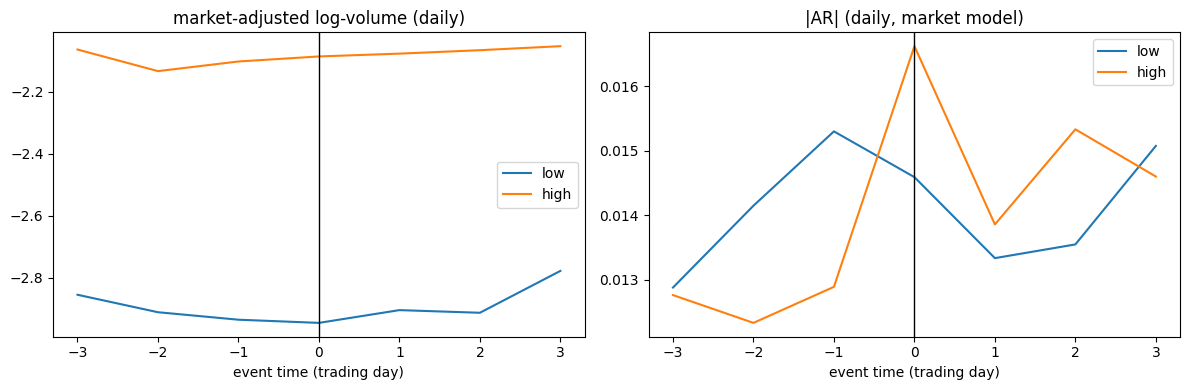

In [12]:
# Plot: event-time pattern (high vs low novelty) for abvol_mkt and |AR|

# NOTE: For plotting event-time, we need per-day series. We'll approximate by computing window panels for a smaller sample.
PLOT_SAMPLE_N = 400
plot_df = df.sample(n=min(PLOT_SAMPLE_N, len(df)), random_state=SAMPLE_SEED).copy()

# split high/low by median novelty
plot_df['nov'] = pd.to_numeric(plot_df[NOVELTY_COL], errors='coerce')
med = plot_df['nov'].median()
plot_df['grp'] = np.where(plot_df['nov']>=med, 'high', 'low')

# compute event-time series [-3,+3]
WIN = (-3,3)
series=[]
for r in plot_df.itertuples(index=False):
    code=str(r.security_code).zfill(5)
    g = stock_by.get(code)
    if g is None or g.empty:
        continue
    evdf = event_window_panel(g, pd.to_datetime(r.submit_ts), WIN)
    if evdf is None:
        continue
    # event-time index: 0..len-1 mapped to [-3..+3] by order
    evdf = evdf.sort_values('date').reset_index(drop=True)
    # map relative day by position (works because shift_td uses trading-day steps)
    rel = list(range(WIN[0], WIN[1]+1))
    if len(evdf) != len(rel):
        continue
    tmp = pd.DataFrame({
        'rel': rel,
        'grp': r.grp,
        'abvol_mkt_daily': evdf['avol'].astype(float),
        'abs_ar': np.abs(evdf['ar'].astype(float)),
    })
    series.append(tmp)

ser = pd.concat(series, ignore_index=True)
agg = ser.groupby(['grp','rel']).mean().reset_index()

fig,ax = plt.subplots(1,2, figsize=(12,4))
for grp in ['low','high']:
    s = agg[agg['grp']==grp]
    ax[0].plot(s['rel'], s['abvol_mkt_daily'], label=grp)
    ax[1].plot(s['rel'], s['abs_ar'], label=grp)

ax[0].axvline(0, color='k', linewidth=1)
ax[0].set_title('market-adjusted log-volume (daily)')
ax[0].set_xlabel('event time (trading day)')
ax[0].legend()

ax[1].axvline(0, color='k', linewidth=1)
ax[1].set_title('|AR| (daily, market model)')
ax[1].set_xlabel('event time (trading day)')
ax[1].legend()

plt.tight_layout()
plt.show()

